# 03 Q3 Design Justification

Main-body figure notebook for temporal decomposition and routing organization.

In [6]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import real_final_viz_helpers as viz
importlib.reload(viz)

annotate_demo  = viz.annotate_demo
apply_style    = viz.apply_style
bar_line_panel = viz.bar_line_panel
load_csv       = viz.load_csv
preview_frame  = viz.preview_frame
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
panel_label    = viz.panel_label

In [7]:
q3_temporal = load_csv('q3_temporal_decomp.csv')
q3_org = load_csv('q3_routing_org.csv')
preview_frame(q3_temporal)

rows=18 cols=12
['dataset', 'variant_label', 'variant_group', 'variant_order', 'panel_family', 'setting_key', 'test_ndcg20', 'test_hit10', 'test_mrr20', 'base_rank', 'seed_id', 'data_status']


,dataset,variant_label,variant_group,variant_order,panel_family,setting_key,test_ndcg20,test_hit10,test_mrr20,base_rank,seed_id,data_status
0,KuaiRecLargeStrictPosV2_0.2,Single-view,single_view,1,temporal_decomp,single_view_micro,0.346393,0.359462,0.337384,1,1,real
1,KuaiRecLargeStrictPosV2_0.2,Best 2-view,best_two_view,2,temporal_decomp,two_view_remove_micro,0.350043,0.357223,0.339767,1,1,real
2,KuaiRecLargeStrictPosV2_0.2,Final 3-stage,final_three_stage,3,temporal_decomp,final_three_stage,0.346305,0.357223,0.336923,1,1,real
3,KuaiRecLargeStrictPosV2_0.2,Single-view,single_view,1,temporal_decomp,single_view_mid,0.346136,0.352744,0.338962,2,1,real
4,KuaiRecLargeStrictPosV2_0.2,Best 2-view,best_two_view,2,temporal_decomp,two_view_remove_macro,0.345138,0.352744,0.337155,2,1,real


In [8]:
apply_style()

# Q3(a): temporal decomposition variants.
temporal_plot = (
    q3_temporal
    .groupby(['variant_label', 'variant_order'], as_index=False)[['test_ndcg20', 'test_hit10']]
    .mean()
    .sort_values('variant_order', kind='stable')
)

# Q3(b): routing organization variants.
org_plot = (
    q3_org
    .groupby(['variant_label', 'variant_order'], as_index=False)[['test_ndcg20', 'test_hit10']]
    .mean()
    .sort_values('variant_order', kind='stable')
)


[saved] fig_q3_design_justification_a.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures


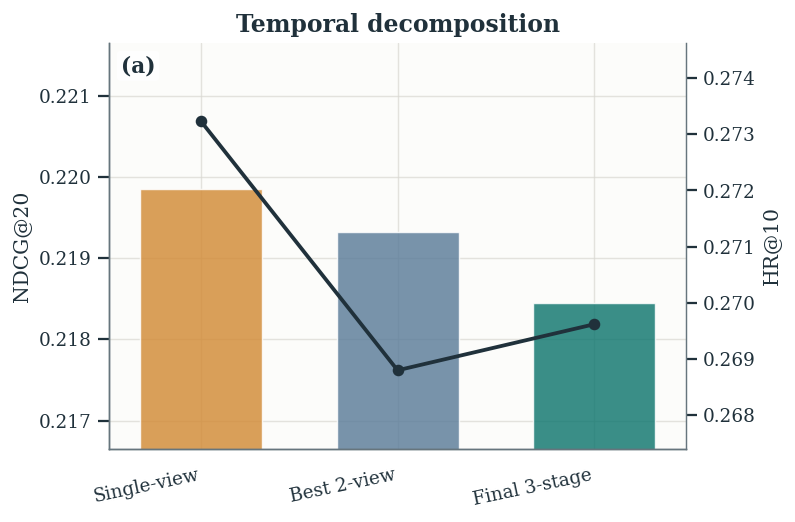

In [9]:
# (a) Temporal decomposition matters.
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.9), constrained_layout=True)

bar_line_panel(
    temporal_plot,
    category_col='variant_label',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    order=temporal_plot['variant_label'].tolist(),
    ax=ax,
    title='Temporal decomposition',
    xrotation=12,
)
panel_label(ax, 'a')

_fig_dir = (Path('..') / 'ACM_template' / 'figures').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'fig_q3_design_justification_a.pdf', bbox_inches='tight')
print(f'[saved] fig_q3_design_justification_a.pdf  -> {_fig_dir}')
plt.show()

[saved] fig_q3_design_justification_b.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures


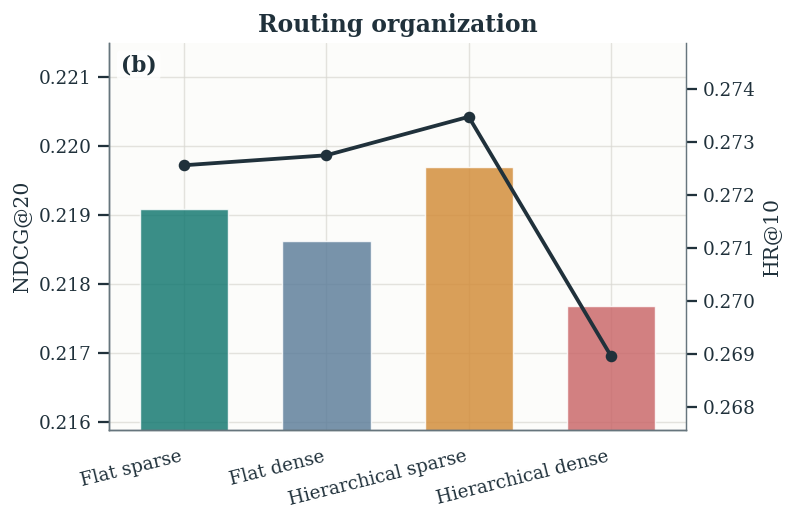

In [10]:
# (b) Hierarchical sparse routing matters.
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.9), constrained_layout=True)

bar_line_panel(
    org_plot,
    category_col='variant_label',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    order=org_plot['variant_label'].tolist(),
    ax=ax,
    title='Routing organization',
    xrotation=14,
)
panel_label(ax, 'b')

_fig_dir = (Path('..') / 'ACM_template' / 'figures').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'fig_q3_design_justification_b.pdf', bbox_inches='tight')
print(f'[saved] fig_q3_design_justification_b.pdf  -> {_fig_dir}')
plt.show()